In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# Softmax Classifier exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [1]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Preprocessing

In [2]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


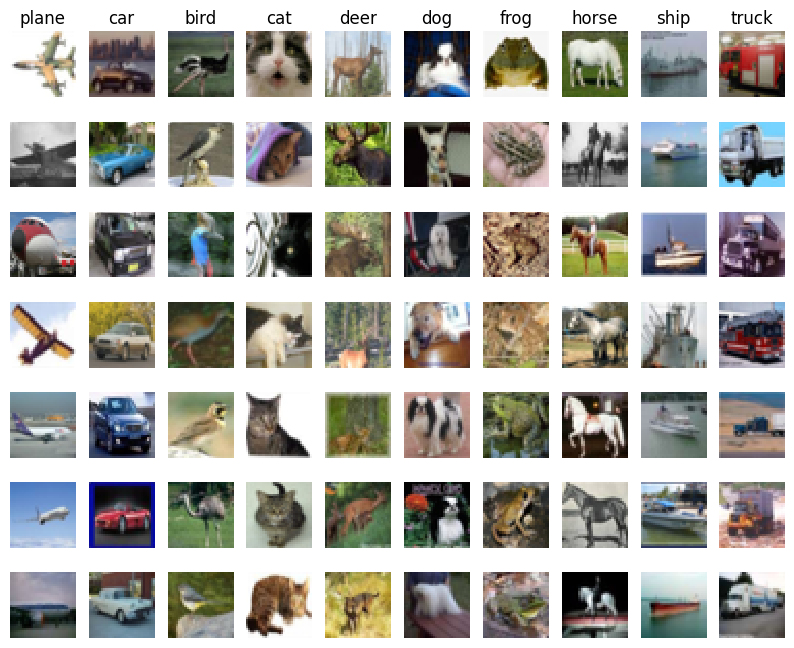

In [3]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [5]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


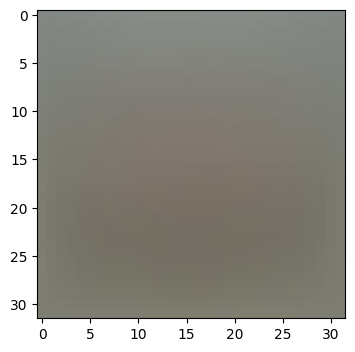

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [6]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax Classifier

Your code for this section will all be written inside `cs231n/classifiers/softmax.py`.

As you can see, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

In [7]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.295402
loss: 2.295402
sanity check: 2.302585


**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.

$\color{blue}{\textit Your Answer:}$  
\begin{align}
s^{(i)} &= x^{(i)}W \nonumber \\
p_j^{(i)} &= \frac{e^{s_j^{(i)}}}{\sum_{k=1}^n e^{s_k^{(i)}}} \nonumber \\
L^{(i)} &= -\log(p_{y_{t_i}^{(i)}}^{(i)}) \nonumber \\
L &= \frac{1}{N} \sum_{i=1}^N L^{(i)} + \lambda ||W||^2 \nonumber
\end{align}
where $n$ is the number of classes, $N$ is the number of training data, $x^{(i)}$ is the feature of the $i$-th training data, $y_{t_i}^{(i)}$ is the true class label of the $i$-th training data, $s^{(i)}$ is the score vector for each class of the $i$-th training data, $p_j^{(i)}$ is the predicted possibility for $j$-th class of the $i$-th training data, $L$is the loss.  
  
For all $x$ in dataset, $$y_{t_i}^{(i)} \sim \mathrm{Uniform}\{1, n\}$$
For the initial state, 
$$W \sim \mathcal{N}(0, \sigma^2 I) \quad (\sigma = 0.0001) \\
\quad \\ W \approx 0 \\
s^{(i)} \approx x^{(i)}0 = 0 \\
p_j^{(i)} \approx \frac{e^{0}}{\sum_{k=1}^n e^{0}} = \frac{1}{n} \\
L_{(i)} =  -\log(p_{y_{t_i}^{(i)}}^{(i)}) \approx -\log(\frac{1}{n}) = -\log(\frac{1}{n}) \\
\lambda ||W||^2 = \lambda dn \sigma^2 \\
L \approx -\log(\frac{1}{n}) + \lambda dn \sigma^2$$
For CIFAR-10 dataset, $n$=10, $\lambda dn \sigma^2 = 0.000005 * 3073 * 10 * 0.0001^2 \approx 0$, $L \approx -\log(\frac{1}{10})$.


The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

In [8]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 0.183746 analytic: 0.183746, relative error: 2.249785e-07
numerical: -0.322043 analytic: -0.322043, relative error: 1.821770e-08
numerical: 0.509367 analytic: 0.509367, relative error: 4.381963e-08
numerical: -2.341478 analytic: -2.341478, relative error: 3.579884e-09
numerical: -4.332049 analytic: -4.332049, relative error: 9.251576e-09
numerical: 0.579164 analytic: 0.579164, relative error: 1.194495e-07
numerical: 0.544064 analytic: 0.544064, relative error: 4.687976e-08
numerical: -0.231765 analytic: -0.231765, relative error: 4.831307e-08
numerical: -0.600032 analytic: -0.600032, relative error: 1.342960e-07
numerical: -0.666698 analytic: -0.666698, relative error: 6.411989e-08
numerical: -1.574459 analytic: -1.574459, relative error: 2.393938e-08
numerical: -2.275943 analytic: -2.275943, relative error: 1.081048e-08
numerical: 3.964275 analytic: 3.964275, relative error: 1.057043e-08
numerical: 1.470519 analytic: 1.470519, relative error: 3.938444e-08
numerical: -0.2045

\begin{align}
s^{(i)} &= x^{(i)}W \nonumber \\
s^{(i)}_j &= \sum_{l=1}^d x^{(i)}_l W_{l,j} \nonumber \\
\frac{\partial s^{(i)}_j}{\partial W_{l,j}} &= x^{(i)}_l \nonumber \\
\frac{\partial s^{(i)}_{k(k \neq j)}}{\partial W_{l,j}} &= 0 \nonumber \\
\frac{\partial L^{(i)}}{\partial W_{l,j}} &= \sum_{k=1}^n \frac{\partial s^{(i)}_k}{\partial W_{l,j}} \frac{\partial L^{(i)}}{\partial s^{(i)}_k}  \nonumber \\
&= x^{(i)}_l \frac{\partial L^{(i)}}{\partial s^{(i)}_j} \nonumber \\
\frac{\partial L^{(i)}}{\partial W} &= x^\top \frac{\partial L^{(i)}}{\partial s^{(i)}} \nonumber \\
\quad \nonumber \\
p^{(i)}_j &= \frac{e^{s^{(i)}_j}}{\sum_{l=1}^n e^{s^{(i)}_l}} \nonumber \\
L^{(i)} &= -\log{p^{(i)}_{y^{(i)}_{t^{(i)}}}} \nonumber \\
\frac{\partial L^{(i)}}{\partial p^{(i)}_{y^{(i)}_{t^{(i)}}}} &= -\frac{1}{p^{(i)}_{y^{(i)}_{t^{(i)}}}} \nonumber \\
\frac{\partial L^{(i)}}{\partial p^{(i)}_{k(k \neq y^{(i)}_{t^{(i)}})}} &= 0 \nonumber \\
\frac{\partial p^{(i)}_j}{\partial s^{(i)}_j} &= \frac{e^{s^{(i)}_j} \sum_{l=1}^n e^{s^{(i)}_l} - e^{s^{(i)}_j} e^{s^{(i)}_j}}{(\sum_{l=1}^n e^{s^{(i)}_l})^2} \nonumber \\
&= p^{(i)}_j (1-p^{(i)}_j) \nonumber \\
\frac{\partial p^{(i)}_{k(k \neq j)}}{\partial s^{(i)}_j} &= \frac{- e^{s^{(i)}_j} e^{s^{(i)}_{k(k \neq j)}}}{(\sum_{l=1}^n e^{s^{(i)}_l})^2} \nonumber \\
&= -p^{(i)}_j p^{(i)}_{k(k \neq j)} \nonumber \\
\frac{\partial L^{(i)}}{\partial s^{(i)}_j} &= \sum_{k=1}^n \frac{\partial p^{(i)}_k}{\partial s^{(i)}_j} \frac{\partial L^{(i)}}{\partial p^{(i)}_k} \nonumber \\
&= p^{(i)}_j \frac{\partial L^{(i)}}{\partial p^{(i)}_j} + \sum_{k=1}^n -p^{(i)}_j p^{(i)}_k \frac{\partial L^{(i)}}{\partial p^{(i)}_k} \nonumber \\
&= p^{(i)}_j \frac{\partial L^{(i)}}{\partial p^{(i)}_j} - p^{(i)}_j p^{(i)}_{y^{(i)}_{t^{(i)}}} (-\frac{1}{p^{(i)}_{y^{(i)}_{t^{(i)}}}}) \nonumber \\
&= p^{(i)}_j (\frac{\partial L^{(i)}}{\partial p^{(i)}_j} + 1) \nonumber \\
\frac{\partial L^{(i)}}{\partial s^{(i)}_{y^{(i)}_{t^{(i)}}}} &= p^{(i)}_{t^{(i)}} (-\frac{1}{p^{(i)}_{y^{(i)}_{t^{(i)}}}} + 1) \nonumber \\
&= p^{(i)}_{t^{(i)}} - 1 \nonumber \\
\frac{\partial L^{(i)}}{\partial s^{(i)}_j(j \neq {y^{(i)}_{t^{(i)}}})} &= p^{(i)}_j(j \neq {y^{(i)}_{t^{(i)}}}) \nonumber \\
\frac{\partial L^{(i)}}{\partial s^{(i)}} &= p^{(i)} - \mathbf{1}_{t^{(i)}} \nonumber \\
\quad \nonumber \\
L &= \frac{1}{N} \sum_{i=1}^N L^{(i)} + \lambda ||W||^2 \nonumber \\
\frac{\partial L}{\partial W} &= \frac{1}{N} \sum_{i=1}^N \frac{\partial L^{(i)}}{\partial W} + 2\lambda W \nonumber \\
\frac{\partial L}{\partial \theta_{k(\theta_k \neq W)}} &= \frac{1}{N} \sum_{i=1}^N \frac{\partial L^{(i)}}{\partial \theta_{k(\theta_k \neq W)}} \nonumber
\end{align}

**Inline Question 2**

Although gradcheck is reliable softmax loss, it is possible that for SVM loss, once in a while, a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a svm loss gradient check could fail? How would change the margin affect of the frequency of this happening?

Note that SVM loss for a sample $(x_i, y_i)$ is defined as: $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ where $j$ iterates over all classes except the correct class $y_i$ and $s_j$ denotes the classifier score for $j^{th}$ class. $\Delta$ is a scalar margin. For more information, refer to 'Multiclass Support Vector Machine loss' on [this](https://cs231n.github.io/linear-classify/) page.

*Hint: the SVM loss function is not strictly speaking differentiable.*


$\color{blue}{\textit Your Answer:}$  
For each score of an incorrect class for a sample, the SVM loss function is not differentiable when $s_j - s_{y_i} + \Delta = 0$ and analytic gradient will be a predefined value between 0 and 1 (usually 1), while the gradcheck approximates with secant slope numerical gradient and the numerical gradient will be 0.5, which causes the mismatch.  
Changing the margin would affect the probability of $s_{y_i}$ equal to $s_j + \Delta$ because $s_{y_i}$ is less possible to be larger, and thus affect the frequency of this mismatch.


In [9]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.295402e+00 computed in 0.055666s
Vectorized loss: 2.295402e+00 computed in 0.008675s
difference: -0.000000


In [10]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.079792s
Vectorized loss and gradient: computed in 0.007213s
difference: 0.000000


### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

In [11]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 777.205275
iteration 100 / 1500: loss 285.544469
iteration 200 / 1500: loss 105.751388
iteration 300 / 1500: loss 40.066695
iteration 400 / 1500: loss 15.967656
iteration 500 / 1500: loss 7.160306
iteration 600 / 1500: loss 3.938445
iteration 700 / 1500: loss 2.750049
iteration 800 / 1500: loss 2.353604
iteration 900 / 1500: loss 2.164031
iteration 1000 / 1500: loss 2.134157
iteration 1100 / 1500: loss 2.114439
iteration 1200 / 1500: loss 2.043293
iteration 1300 / 1500: loss 2.137460
iteration 1400 / 1500: loss 2.130903
That took 8.818387s


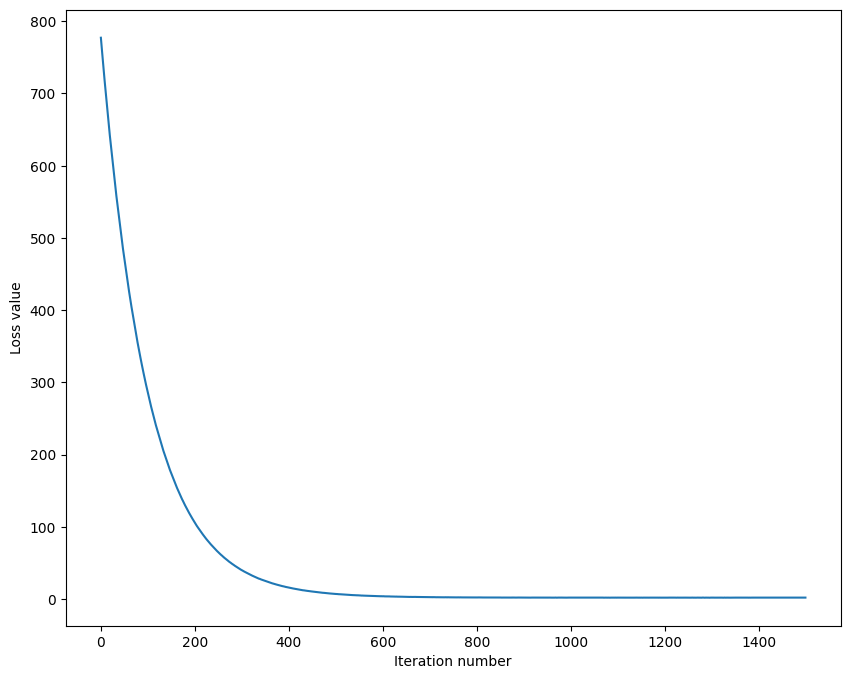

In [12]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [13]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.330816
validation accuracy: 0.345000


In [14]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [15]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.365 (> 0.36) on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

################################################################################
# TODO:                                                                        #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################

# Provided as a reference. You may or may not want to change these hyperparameters
'''
learning_rates = [1e-7, 5e-7, 1e-6, 2e-6]
regularization_strengths = [1e4, 5e3, 1e3, 2.5e2]
hyperparameters = [(lr, reg) for lr in learning_rates for reg in regularization_strengths] + [(1e-5, 1e3), (1e-6, 1)]

lr 1.000000e-07 reg 2.500000e+02 train accuracy: 0.250306 val accuracy: 0.264000
lr 1.000000e-07 reg 1.000000e+03 train accuracy: 0.265612 val accuracy: 0.276000
lr 1.000000e-07 reg 5.000000e+03 train accuracy: 0.330020 val accuracy: 0.331000
lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.352388 val accuracy: 0.371000
lr 5.000000e-07 reg 2.500000e+02 train accuracy: 0.341612 val accuracy: 0.352000
lr 5.000000e-07 reg 1.000000e+03 train accuracy: 0.384122 val accuracy: 0.395000
lr 5.000000e-07 reg 5.000000e+03 train accuracy: 0.371551 val accuracy: 0.384000
lr 5.000000e-07 reg 1.000000e+04 train accuracy: 0.352959 val accuracy: 0.361000
lr 1.000000e-06 reg 1.000000e+00 train accuracy: 0.350367 val accuracy: 0.348000
lr 1.000000e-06 reg 2.500000e+02 train accuracy: 0.388510 val accuracy: 0.396000
lr 1.000000e-06 reg 1.000000e+03 train accuracy: 0.400163 val accuracy: 0.401000
lr 1.000000e-06 reg 5.000000e+03 train accuracy: 0.364449 val accuracy: 0.373000
lr 1.000000e-06 reg 1.000000e+04 train accuracy: 0.349449 val accuracy: 0.351000
lr 2.000000e-06 reg 2.500000e+02 train accuracy: 0.404143 val accuracy: 0.389000
lr 2.000000e-06 reg 1.000000e+03 train accuracy: 0.395510 val accuracy: 0.400000
lr 2.000000e-06 reg 5.000000e+03 train accuracy: 0.358551 val accuracy: 0.372000
lr 2.000000e-06 reg 1.000000e+04 train accuracy: 0.339816 val accuracy: 0.337000
lr 1.000000e-05 reg 1.000000e+03 train accuracy: 0.235796 val accuracy: 0.241000
'''
hyperparameters = []
hyperparameter_range = {
    'lr':(-6.5, -5.5),
    'reg':(2, 3.5)
}
for i in range(25):
    lr = 10 ** np.random.uniform(*hyperparameter_range['lr'])
    reg = 10 ** np.random.uniform(*hyperparameter_range['reg'])
    hyperparameters.append((lr, reg))

for lr, reg in hyperparameters:
    softmax = Softmax()
    softmax.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=1500)
    train_accuracy = np.mean(y_train == softmax.predict(X_train))
    val_accuracy = np.mean(y_val == softmax.predict(X_val))
    results[(lr, reg)] = (train_accuracy, val_accuracy)
    if val_accuracy > best_val:
        best_val = val_accuracy
        best_softmax = softmax

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 3.440592e-07 reg 5.509419e+02 train accuracy: 0.335837 val accuracy: 0.332000
lr 3.805726e-07 reg 7.491638e+02 train accuracy: 0.360959 val accuracy: 0.371000
lr 4.808649e-07 reg 1.556939e+03 train accuracy: 0.393898 val accuracy: 0.395000
lr 5.955024e-07 reg 2.997134e+02 train accuracy: 0.358551 val accuracy: 0.383000
lr 5.999234e-07 reg 2.971854e+03 train accuracy: 0.390224 val accuracy: 0.407000
lr 6.002542e-07 reg 1.630802e+02 train accuracy: 0.343102 val accuracy: 0.342000
lr 6.075698e-07 reg 2.879989e+03 train accuracy: 0.381245 val accuracy: 0.382000
lr 6.689325e-07 reg 2.500779e+02 train accuracy: 0.367204 val accuracy: 0.359000
lr 7.927516e-07 reg 1.799443e+03 train accuracy: 0.391224 val accuracy: 0.401000
lr 8.758453e-07 reg 6.313245e+02 train accuracy: 0.397878 val accuracy: 0.392000
lr 1.070958e-06 reg 3.099232e+02 train accuracy: 0.393469 val accuracy: 0.390000
lr 1.073475e-06 reg 1.010632e+03 train accuracy: 0.402388 val accuracy: 0.403000
lr 1.283731e-06 reg 2.229057

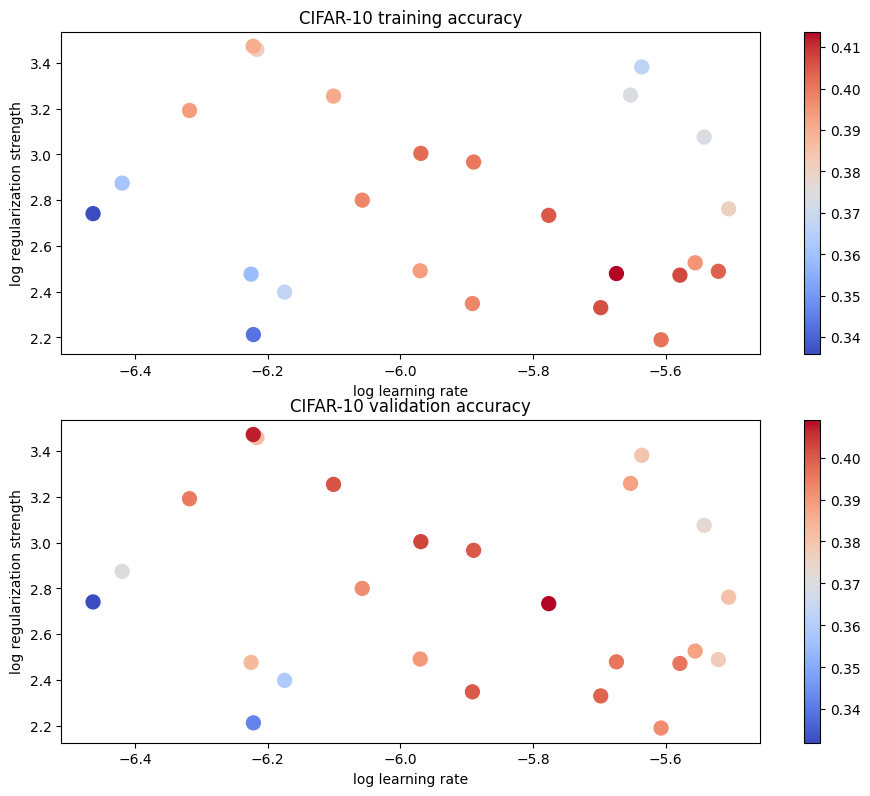

In [16]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [17]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.388000


In [18]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


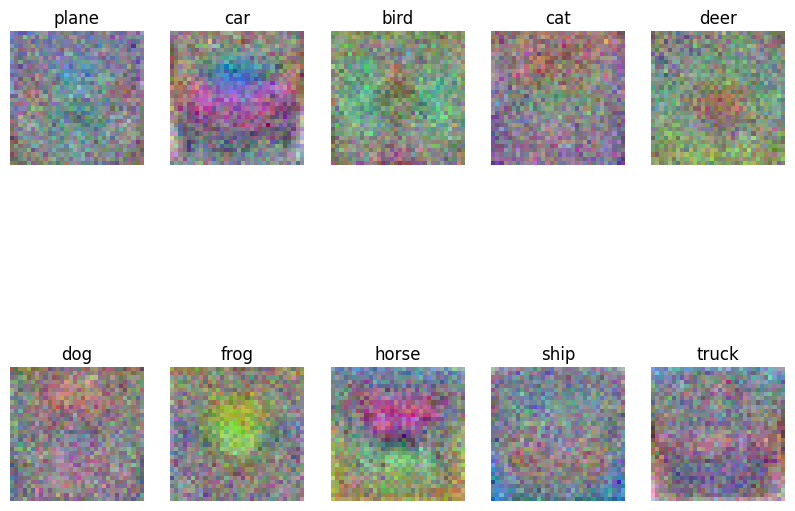

In [19]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textit Your Answer:}$  
Each of the visualized weights look like an instance of the class.  
Softmax classifier uses the dot product of weights and features to compute scores, which is equivalent to computing the similarity between the image with each templete of a class the weights represent.


**Inline Question 4** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.

$\color{blue}{\textit Your Answer:}$ True


$\color{blue}{\textit Your Explanation:}$  
Condition for softmax loss unchanged:
$$ \Delta L_{softmax} = -\log \left(\frac{e^{s_{y_{N+1}}^{(N+1)}}}{\sum_{j} e^{s_j^{(N+1)}}}\right) = 0 \\
\frac{e^{s_{y_{N+1}}^{(N+1)}}}{\sum_{j} e^{s_j^{(N+1)}}} = 1 \\
\sum_{j} e^{s_j^{(N+1)} - s_{y_{N+1}}^{(N+1)}} = 1 \\
\sum_{j \neq y_{N+1}} e^{s_j^{(N+1)} - s_{y_{N+1}}^{(N+1)}} = 0 \\
\forall j \neq y_{N+1}, \quad e^{s_j^{(N+1)} - s_{y_{N+1}}^{(N+1)}} = 0 \\
\forall j \neq y_{N+1}, \quad s_j^{(N+1)} - s_{y_{N+1}}^{(N+1)} \to -\infty \\
\forall j \neq y_{N+1}, \quad s_{y_{N+1}}^{(N+1)} \gg s_j^{(N+1)}
$$
Condition for SVM loss unchanged:
$$ \Delta L_{SVM} = \sum_{j \neq y_{N+1}} \max\{0, s_j^{(N+1)} - s_{y_{N+1}}^{(N+1)} + \Delta\} = 0 \\
\forall j \neq y_{N+1}, \quad s_j^{(N+1)} - s_{y_{N+1}}^{(N+1)} + \Delta \leq 0 \\
\forall j \neq y_{N+1}, \quad s_{y_{N+1}}^{(N+1)} \geq s_j^{(N+1)} + \Delta$$
Given a small $\Delta$, it is possible to have every difference $s_j^{(N+1)} - s_{y_{N+1}}^{(N+1)}$ for all $j \neq y_{N+1}$ larger than $\Delta$ but not overflow.


